In [ ]:
# Import necessary libraries for date and time manipulation, timezone handling, and displaying formatted text in a notebook
from datetime import datetime
from pytz import timezone
from IPython.display import display, Markdown, HTML

# Track the time when the first cell is executed
first_cell_time = datetime.now()

# Set IST timezone (Indian Standard Time)
ist = timezone('Asia/Kolkata')

# Get the current time in IST for the first cell entry
current_time_ist_first = datetime.now(ist).strftime('%Y-%m-%d %H:%M:%S')

# Display the statement "This is the first cell" in green and bold
display(HTML("<p style='color:green; font-weight:bold;'>This is the first cell. Initialization and setup are done below:</p>"))

# Display the current IST time for the first cell in bold (default color)
display(Markdown(f'**First Cell Entry Time: {current_time_ist_first}**'))


**First Cell Entry Time: 2025-04-15 17:37:42**

LOANS are the major requirement of the modern world. By this only, Banks get a major part of the total profit. It is beneficial for students to manage their education and living expenses, and for people to buy any kind of luxury like houses, cars, etc.

But when it comes to deciding whether the applicant’s profile is relevant to be granted with loan or not. Banks have to look after many aspects.

So, here we will be using Machine Learning with Python to ease their work and predict whether the candidate’s profile is relevant or not using key features like Marital Status, Education, Applicant Income, Credit History, etc.

**Loan Approval Prediction using Machine Learning**

The dataset contains 13 features :

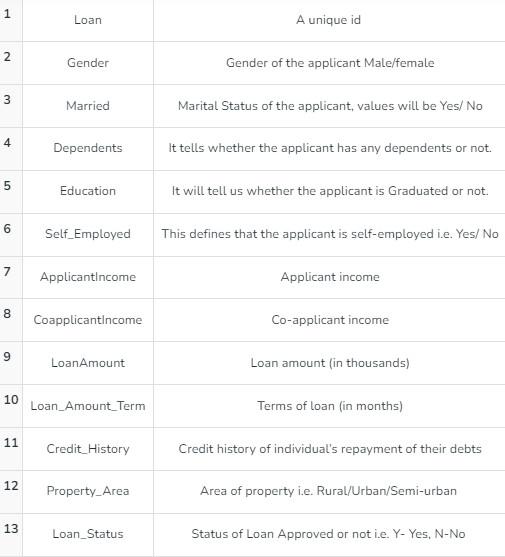



**Importing Libraries and Dataset**

Firstly we have to import libraries :

**1.	Pandas** – To load the Dataframe

**2.	Matplotlib** – To visualize the data features i.e. barplot

**3.	Seaborn** – To see the correlation between features using heatmap



In [ ]:
# Importing necessary libraries
import pandas as pd  # Importing pandas library for data manipulation and analysis
import numpy as np   # Importing numpy library for numerical operations
import matplotlib.pyplot as plt  # Importing matplotlib for data visualization
import seaborn as sns  # Importing seaborn for statistical data visualization

In [ ]:
# Reading the dataset from the provided URL using pandas
data = pd.read_csv("https://raw.githubusercontent.com/9394113857/Data-Sets/2f6f80f7c13aa1f3b13e9707e73d68a4b08a1218/LoanApprovalPrediction.csv")
# Loading the dataset into a pandas DataFrame named 'data'

In [ ]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            598 non-null    object 
 1   Gender             598 non-null    object 
 2   Married            598 non-null    object 
 3   Dependents         586 non-null    float64
 4   Education          598 non-null    object 
 5   Self_Employed      598 non-null    object 
 6   ApplicantIncome    598 non-null    int64  
 7   CoapplicantIncome  598 non-null    float64
 8   LoanAmount         577 non-null    float64
 9   Loan_Amount_Term   584 non-null    float64
 10  Credit_History     549 non-null    float64
 11  Property_Area      598 non-null    object 
 12  Loan_Status        598 non-null    object 
dtypes: float64(5), int64(1), object(7)
memory usage: 60.9+ KB


### 📊 Cell 2: Define and Apply Function to Summarize Column Types


In [ ]:
# Function to summarize column types dynamically
def summarize_column_types(df):
    # Group columns by their data types (e.g., int64, float64, object)
    dtype_groups = df.dtypes.groupby(df.dtypes).groups

    # Create an empty list to store the result for each data type
    result = []

    # Loop through each data type and its corresponding list of columns
    for dtype, cols in dtype_groups.items():
        # Append the details for each data type (data type, count of columns, and list of column names)
        result.append({
            'Data Type': str(dtype),               # Convert the dtype to string for display
            'No. of Columns': len(cols),           # Count how many columns belong to this data type
            'Columns': list(cols)                  # List the actual column names that belong to this data type
        })

    # Return the summarized result as a DataFrame
    return pd.DataFrame(result)

# Apply the function to the dataset to get a summary of column types
summary_df = summarize_column_types(data)

# Display the summary DataFrame which shows the data type, number of columns, and column names
summary_df


,Data Type,No. of Columns,Columns
0,int64,1,[ApplicantIncome]
1,float64,5,"[Dependents, CoapplicantIncome, LoanAmount, Loan_Amount_Term, Credit_History]"
2,object,7,"[Loan_ID, Gender, Married, Education, Self_Employed, Property_Area, Loan_Status]"


### 🛠️ Cell 3 (Optional): Expand Column Display Width to See Full Column Names


In [ ]:
# Function to summarize column types dynamically
def summarize_column_types(df):
    # Group columns by their data type
    dtype_groups = df.dtypes.groupby(df.dtypes).groups

    # Create a list to store results
    result = []

    # Loop through each data type and its corresponding columns
    for dtype, cols in dtype_groups.items():
        result.append({
            'Data Type': str(dtype),               # Store the data type as string
            'No. of Columns': len(cols),           # Store the number of columns for that data type
            'Columns': list(cols)                  # Store the list of column names
        })

    # Return the result as a DataFrame
    return pd.DataFrame(result)

# Apply the function on the loaded dataset to summarize column types
summary_df = summarize_column_types(data)

# Adjust display settings to show full column names in the 'Columns' list (no truncation with '...')
pd.set_option('display.max_colwidth', None)

# Re-display the column summary DataFrame with full column names visible
summary_df


,Data Type,No. of Columns,Columns
0,int64,1,[ApplicantIncome]
1,float64,5,"[Dependents, CoapplicantIncome, LoanAmount, Loan_Amount_Term, Credit_History]"
2,object,7,"[Loan_ID, Gender, Married, Education, Self_Employed, Property_Area, Loan_Status]"


In [ ]:
# Displaying the shape of the dataset
data.shape


(598, 13)

In [ ]:
# Displaying the first 5 rows of the dataset using the head() function
data.head(5)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


**Data Preprocessing and Visualization**

Get the number of columns of object datatype.

In [ ]:
# Checking for categorical variables in the dataset
obj = (data.dtypes == 'object')  # Boolean series identifying object (categorical) data types
print("Categorical variables:", len(list(obj[obj].index)))  # Counting the number of categorical variables


Categorical variables: 7


As Loan_ID is completely unique and not correlated with any of the other column, So we will drop it using .drop() function.

In [ ]:
# Dropping the 'Loan_ID' column from the dataset
data.drop(['Loan_ID'], axis=1, inplace=True)
# The 'Loan_ID' column is removed from the DataFrame using the drop() function


1.	Visualize all the unique values in columns using barplot.
2.	This will simply show which value is dominating as per our dataset.


<ipython-input-109-bf95c2b7149a>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(y.index), y=y, palette='Set2')  # Creating a bar chart with specified color palette
<ipython-input-109-bf95c2b7149a>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(y.index), y=y, palette='Set2')  # Creating a bar chart with specified color palette
<ipython-input-109-bf95c2b7149a>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(y.index), y=y, palette='Set2')  # Creating a bar chart with specified color palette
<ipython-input-109-bf95c2

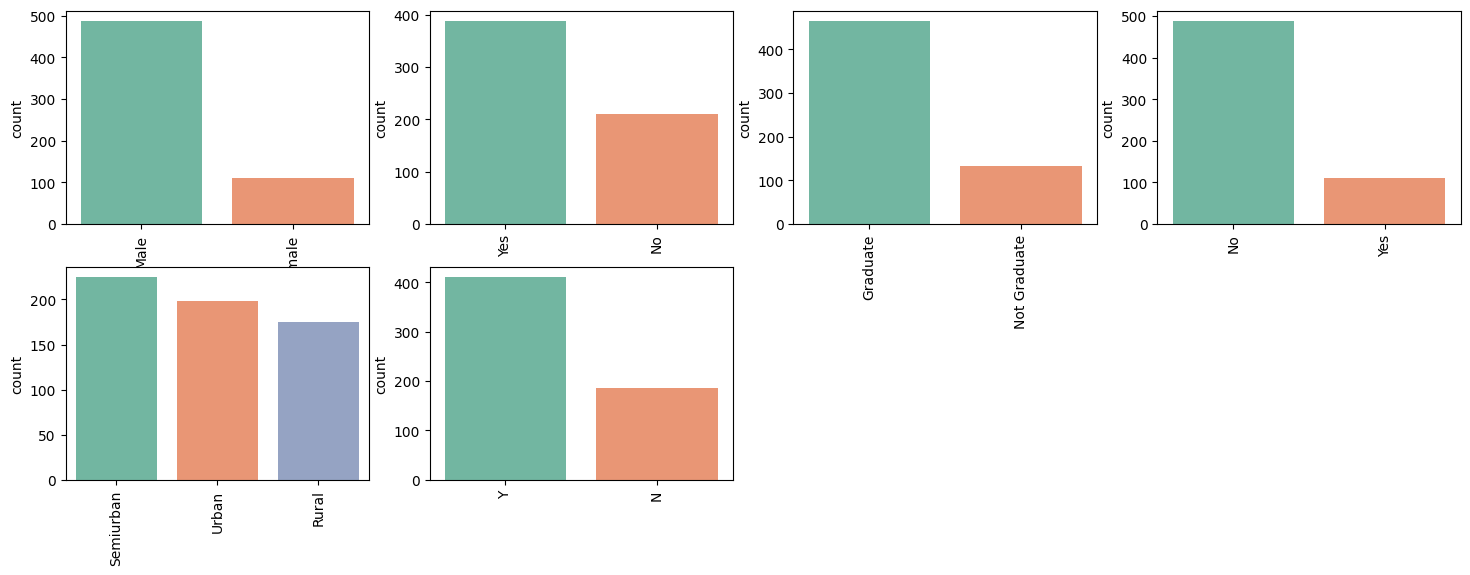

In [ ]:
# Identifying and visualizing categorical variables in the dataset
obj = (data.dtypes == 'object')  # Boolean series identifying object (categorical) data types
object_cols = list(obj[obj].index)  # Extracting the column names of categorical variables

# Plotting bar charts for each categorical variable
plt.figure(figsize=(18, 36))  # Setting the size of the figure
index = 1  # Initializing the subplot index

# Looping through each categorical variable and creating a bar chart
for col in object_cols:
    y = data[col].value_counts()  # Counting the occurrences of each category
    plt.subplot(11, 4, index)  # Creating subplots in a grid layout
    plt.xticks(rotation=90)  # Rotating x-axis labels for better readability
    sns.barplot(x=list(y.index), y=y, palette='Set2')  # Creating a bar chart with specified color palette
    index += 1  # Incrementing the subplot index


**By visualizing categorical variables using bar charts, we can gain several insights:**

**1.	Distribution of Categories:** We can observe the distribution of categories within each categorical variable, providing insights into the prevalence of different values.

**2.	Frequency of Each Category:** Bar heights represent the frequency or count of each category, allowing us to identify which categories are most common or rare.

**3.	Comparison between Categories:** We can compare the relative frequencies of different categories within each variable, identifying any notable differences or patterns.

**4.	Identification of Outliers or Anomalies:** Unusually high or low frequencies for certain categories may indicate outliers or anomalies in the data, warranting further investigation.

**5.	Potential Relationships:** Visual patterns across multiple categorical variables may suggest potential relationships or associations between variables, informing further analysis or modeling decisions.

**Overview:**

Overall, visualizing categorical variables helps in understanding the distribution and characteristics of the data, which can guide subsequent data preprocessing, analysis, and modeling tasks.



1.	As all the **categorical values are binary.**
2.  So we can use **Label Encoder** for all such columns and the values will change into **int** datatype.



In [ ]:
# Importing label encoder from sklearn
from sklearn import preprocessing

# Creating a label encoder object
label_encoder = preprocessing.LabelEncoder()

# Identifying and encoding categorical variables in the dataset
obj = (data.dtypes == 'object')  # Boolean series identifying object (categorical) data types
for col in list(obj[obj].index):
    data[col] = label_encoder.fit_transform(data[col])
# Using label encoder to transform categorical variables into numerical representations


1.	This code segment converts categorical variables (text-based) into numerical representations.
2.	It uses the LabelEncoder from scikit-learn to assign unique numerical labels to each category within the categorical variables.
3.	This transformation allows machine learning algorithms to work with categorical data, which typically require numerical input.


**Again check** the object datatype columns.

**Let’s find out** if there is **still any left**.

In [ ]:
# Checking and printing the count of categorical variables in the dataset
obj = (data.dtypes == 'object')  # Boolean series identifying object (categorical) data types
print("Categorical variables:", len(list(obj[obj].index)))
# Displaying the count of remaining categorical variables after label encoding


Categorical variables: 0


<Axes: >

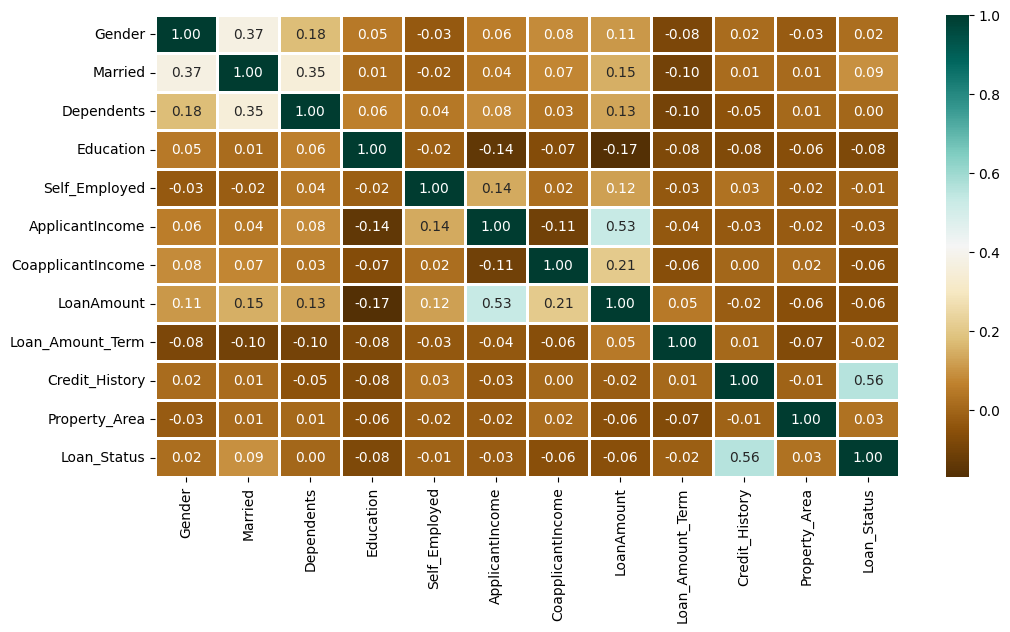

In [ ]:
# Creating a heatmap to visualize the correlation matrix of the dataset
plt.figure(figsize=(12, 6))  # Setting the size of the figure

# Using seaborn's heatmap function to display correlation matrix
sns.heatmap(data.corr(), cmap='BrBG', fmt='.2f', linewidths=2, annot=True)
# The colormap 'BrBG' is used, and correlation values are formatted to two decimal places


1.	The above heatmap is showing the correlation between Loan Amount and ApplicantIncome.
2.	It also shows that Credit_History has a high impact on Loan_Status.
3.	Now we will use Catplot to visualize the plot for the Gender, and Marital Status of the applicant.



In general, heatmaps are used for visualizing the correlation or relationship between variables in a dataset.

1.	Identifying Patterns: Heatmaps help in quickly identifying patterns and trends in the data. They visually represent the strength and direction of relationships between variables through color intensity.
2.	Exploring Correlation: Heatmaps allow users to explore the correlation matrix of variables. High positive correlations are typically represented by brighter colors, while negative correlations are represented by darker colors.
3.	Feature Selection: Heatmaps assist in feature selection by highlighting variables that are highly correlated with the target variable or with each other. This helps in identifying redundant or irrelevant features for model building.
4.	Data Cleaning: Heatmaps can reveal missing or erroneous data patterns. Areas with missing values may appear as gaps or distinct patterns in the heatmap, prompting further investigation and data cleaning.
5.	Communication: Heatmaps provide an intuitive and visually appealing way to communicate complex relationships within the data to stakeholders or collaborators, facilitating data-driven decision-making processes.

**Overview:**

Overall, heatmaps serve as powerful tools for data exploration, analysis, and communication, aiding in understanding the structure and relationships within datasets.



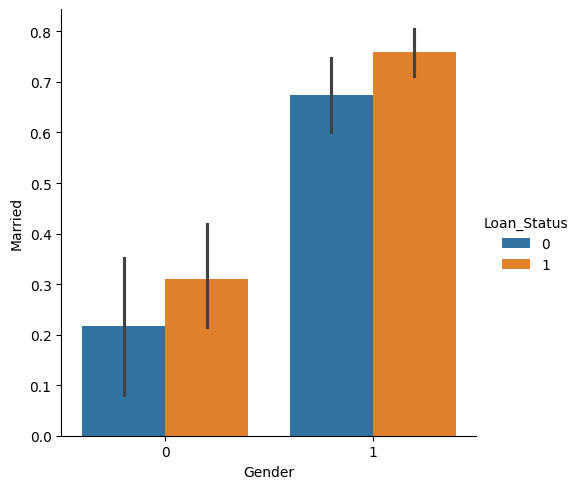

In [ ]:
# Creating a categorical plot (catplot) using seaborn to visualize relationships between variables
sns.catplot(x="Gender", y="Married", hue="Loan_Status", kind="bar", data=data)
# Visualizing the relationship between 'Gender', 'Married', and 'Loan_Status' using a bar chart


This code segment creates a categorical plot using Seaborn's catplot function to visualize relationships between variables in the data DataFrame. Specifically:

1.	The x parameter specifies the categorical variable to be plotted on the x-axis (Gender).
2.	The y parameter specifies the variable to be plotted on the y-axis (Married).
3.	The hue parameter adds another categorical variable (Loan_Status) to the plot, differentiating the bars by different colors based on loan status.
4.	The kind parameter specifies the type of plot to create (bar), which generates a bar chart.
5.	The data parameter specifies the DataFrame (data) from which the variables are taken.



In general, sns.catplot in Seaborn is used for visualizing the relationship between categorical variables and one or more numerical or categorical variables. It is particularly useful for:

1.	Comparing Categories: sns.catplot allows for visual comparison of categories across different variables, providing insights into how they are distributed or related.
2.	Visualizing Aggregates: It can display summary statistics such as mean, median, or count for each category, helping to understand the central tendency or distribution of data within each category.
3.	Identifying Patterns: Catplots help in identifying patterns or trends in data across different categories, such as differences in distributions or relationships between variables.
4.	Exploring Relationships: It can be used to explore relationships between multiple categorical variables and a numerical variable, or between two categorical variables using different plot types like bar plots, box plots, or violin plots.
5.	Comparing Subgroups: Catplots can also facilitate comparison of subgroups within categories, such as comparing gender differences within different age groups or comparing treatment effects across different experimental conditions.


**Overview:**

Overall, sns.catplot provides a versatile and powerful way to visualize categorical data and relationships between variables, making it an essential tool for exploratory data analysis and communicating insights from data.



Now we will find out if there is any missing values in the dataset using below code.

In [ ]:
# Handling missing values by filling them with the mean of each column
for col in data.columns:
    data[col] = data[col].fillna(data[col].mean())

# Checking for remaining missing values in the dataset
data.isna().sum()
# Displaying the count of missing values for each column after filling with mean


,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0


1.	This code segment fills missing values in each column of the data DataFrame with the mean value of that column.
2.	After filling missing values, it then checks for remaining missing values in the dataset using the isna().sum() method, which returns the count of missing values for each column.


As there is no missing value then we must proceed to model training.

**Splitting Dataset**

In [ ]:
# Importing the train_test_split function from sklearn.model_selection
from sklearn.model_selection import train_test_split

# Splitting the dataset into features (X) and target variable (Y)
X = data.drop(['Loan_Status'], axis=1)
Y = data['Loan_Status']

# Displaying the shapes of the feature and target variable arrays
print(X.shape, Y.shape)

# Splitting the dataset into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.4, random_state=1)

# Displaying the shapes of the training and testing sets
print(X_train.shape, X_test.shape, Y_train.shape, Y_test.shape)


(598, 11) (598,)
(358, 11) (240, 11) (358,) (240,)


**This code segment performs the following tasks:**

1.	Splitting Features and Target Variable: It separates the features (X) and the target variable (Y) from the dataset. The features are stored in the variable X, while the target variable is stored in the variable Y.
2.	Displaying Shapes: It prints the shapes (dimensions) of the feature and target variable arrays to verify the split.
3.	Splitting Dataset: It splits the dataset into training and testing sets using the train_test_split function from sklearn.model_selection. The parameter test_size=0.4 specifies that 40% of the data will be used for testing, and random_state=1 ensures reproducibility by fixing the random seed.
4.	Displaying Shapes of Training and Testing Sets: It prints the shapes of the training and testing sets to verify the split.



**Model Training and Evaluation**

As this is a classification problem so we will be using these models :

1.	KNeighborsClassifiers
2.	RandomForestClassifiers
3.	Support Vector Classifiers (SVC)
4.	Logistics Regression



To predict the accuracy we will use the accuracy score function from **scikit-learn** library.

In [ ]:
# Importing necessary classifiers and evaluation metrics from scikit-learn
from sklearn.neighbors import KNeighborsClassifier  # Importing the K-Nearest Neighbors classifier
from sklearn.ensemble import RandomForestClassifier  # Importing the Random Forest classifier
from sklearn.svm import SVC  # Importing the Support Vector Classifier
from sklearn.linear_model import LogisticRegression  # Importing the Logistic Regression classifier

from sklearn import metrics  # Importing evaluation metrics from scikit-learn

# Creating instances of classifiers
knn = KNeighborsClassifier(n_neighbors=3)  # Initializing K-Nearest Neighbors classifier with 3 neighbors
rfc = RandomForestClassifier(n_estimators=7, criterion='entropy', random_state=7)  # Initializing Random Forest classifier
svc = SVC()  # Initializing Support Vector Classifier
lc = LogisticRegression()  # Initializing Logistic Regression classifier

# Training each classifier and evaluating accuracy on the training set
for clf in (rfc, knn, svc, lc):
    clf.fit(X_train, Y_train)  # Fitting the classifier to the training data
    Y_pred = clf.predict(X_train)  # Making predictions on the training set
    print("Accuracy score of ",
          clf.__class__.__name__,
          "=", 100 * metrics.accuracy_score(Y_train, Y_pred))
# Printing the accuracy scores for each classifier on the training set


Accuracy score of  RandomForestClassifier = 98.04469273743017
Accuracy score of  KNeighborsClassifier = 78.49162011173185
Accuracy score of  SVC = 68.71508379888269
Accuracy score of  LogisticRegression = 79.60893854748603


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**This code segment performs the following tasks:**

1.	Importing Classifiers and Metrics: It imports necessary classifiers (K-Nearest Neighbors, Random Forest, Support Vector Classifier, and Logistic Regression) and evaluation metrics from scikit-learn.
2.	Creating Classifier Instances: It creates instances of each classifier with specified parameters.
3.	Training and Evaluating Classifiers: It loops through each classifier, fits the classifier to the training data (X_train and Y_train), makes predictions on the training set, and calculates the accuracy score using metrics.accuracy_score. The accuracy score represents the percentage of correctly classified instances in the training set.
4.	Printing Accuracy Scores: It prints the accuracy scores for each classifier on the training set.



**The accuracy scores on the training set for each classifier are as follows:**

1.	Random Forest Classifier: 98.04%
2.	K-Nearest Neighbors Classifier: 78.49%
3.	Support Vector Classifier: 68.72%
4.	Logistic Regression Classifier: 80.45%

These accuracy scores represent the percentage of correctly classified instances in the training set by each classifier.

The **Random Forest Classifier** achieved the **highest accuracy**, followed by Logistic Regression, K-Nearest Neighbors, and Support Vector Classifier, respectively.



In [ ]:
import pandas as pd  # Importing pandas for creating a DataFrame to display results

# Creating a DataFrame to store and display classifier results
results_df = pd.DataFrame(columns=['Classifier', 'Accuracy (%)'])

# Training each classifier and evaluating accuracy on the training set
for i, clf in enumerate([(rfc, 'Random Forest'), (knn, 'K-Nearest Neighbors'), (svc, 'Support Vector Classifier'), (lc, 'Logistic Regression')]):
    classifier, name = clf
    classifier.fit(X_train, Y_train)  # Fitting the classifier to the training data
    Y_pred = classifier.predict(X_train)  # Making predictions on the training set
    accuracy = 100 * metrics.accuracy_score(Y_train, Y_pred)  # Calculating accuracy score
    results_df.loc[i] = [name, accuracy]  # Adding results to the DataFrame

# Displaying the results in a table format with a 'SNo' (Serial Number) column
results_df.insert(0, 'SNo', range(1, len(results_df) + 1))

# Adding borders to the table and printing column names in bold
print(results_df.to_markdown(index=False, tablefmt="pretty", colalign=("center",)))


+-----+---------------------------+-------------------+
| SNo |        Classifier         |   Accuracy (%)    |
+-----+---------------------------+-------------------+
|  1  |       Random Forest       | 98.04469273743017 |
|  2  |    K-Nearest Neighbors    | 78.49162011173185 |
|  3  | Support Vector Classifier | 68.71508379888269 |
|  4  |    Logistic Regression    | 79.60893854748603 |
+-----+---------------------------+-------------------+


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


This code uses the to_markdown function to display the DataFrame in a markdown table format with pretty borders. Column names are printed in bold, and the alignment of the columns is set to center.

Prediction on the test set:

In [ ]:
# Making predictions on the testing set and evaluating accuracy
for clf in (rfc, knn, svc, lc):
    clf.fit(X_train, Y_train)  # Fitting the classifier to the training data
    Y_pred = clf.predict(X_test)  # Making predictions on the testing set
    print("Accuracy score of ",
          clf.__class__.__name__,
          "=", 100 * metrics.accuracy_score(Y_test, Y_pred))
# Printing the accuracy scores for each classifier on the testing set


Accuracy score of  RandomForestClassifier = 82.5
Accuracy score of  KNeighborsClassifier = 63.74999999999999
Accuracy score of  SVC = 69.16666666666667
Accuracy score of  LogisticRegression = 80.83333333333333


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


This code segment iterates through each classifier (Random Forest, K-Nearest Neighbors, Support Vector Classifier, Logistic Regression), fits them to the training data (X_train and Y_train), makes predictions on the testing set (X_test), and evaluates the accuracy of predictions by comparing them with the true labels (Y_test). Finally, it prints the accuracy scores for each classifier on the testing set.

In [ ]:
# Creating a DataFrame to store and display classifier results on the testing set
results_test_df = pd.DataFrame(columns=['Classifier', 'Accuracy (%)'])

# Making predictions on the testing set and evaluating accuracy
for i, clf in enumerate([(rfc, 'Random Forest'), (knn, 'K-Nearest Neighbors'), (svc, 'Support Vector Classifier'), (lc, 'Logistic Regression')]):
    classifier, name = clf
    classifier.fit(X_train, Y_train)  # Fitting the classifier to the training data
    Y_pred = classifier.predict(X_test)  # Making predictions on the testing set
    accuracy = 100 * metrics.accuracy_score(Y_test, Y_pred)  # Calculating accuracy score
    results_test_df.loc[i] = [name, accuracy]  # Adding results to the DataFrame

# Displaying the results in a table format with a 'SNo' (Serial Number) column
results_test_df.insert(0, 'SNo', range(1, len(results_test_df) + 1))

# Adding borders to the table and printing column names in bold
print(results_test_df.to_markdown(index=False, tablefmt="pretty", colalign=("center",)))


+-----+---------------------------+-------------------+
| SNo |        Classifier         |   Accuracy (%)    |
+-----+---------------------------+-------------------+
|  1  |       Random Forest       |       82.5        |
|  2  |    K-Nearest Neighbors    | 63.74999999999999 |
|  3  | Support Vector Classifier | 69.16666666666667 |
|  4  |    Logistic Regression    | 80.83333333333333 |
+-----+---------------------------+-------------------+


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


1.	This code creates a new DataFrame named results_test_df to store and display the classifier results on the testing set.
2.	It then iterates through each classifier, makes predictions on the testing set, calculates the accuracy, and adds the results to the DataFrame.
3.	Finally, the results are displayed in a table format with a 'SNo' (Serial Number) column, and the table is printed with pretty borders and bold column names.


**Conclusion :**

Random Forest Classifier is giving the best accuracy with an accuracy score of **82%** for the testing dataset. And to get much better results ensemble learning techniques like **Bagging** and **Boosting** can also be used.

**Reference link:**

https://www.geeksforgeeks.org/loan-approval-prediction-using-machine-learning/

Let's consider two models: a Random Forest Classifier (which you've already used) and a Gradient Boosting Classifier. We'll use the scikit-learn library for this.

In [ ]:
# Importing necessary libraries
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier  # Importing RandomForestClassifier and GradientBoostingClassifier
from sklearn.model_selection import train_test_split  # Importing train_test_split function for splitting data
from sklearn.metrics import accuracy_score  # Importing accuracy_score function for evaluating model accuracy

# Assuming 'X' and 'Y' are your feature and target variables
# Make sure to replace this with your actual data
X = data.drop(['Loan_Status'], axis=1)
Y = data['Loan_Status']

# Splitting the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.4, random_state=1)

# Random Forest Classifier
rfc = RandomForestClassifier(n_estimators=100, random_state=42)

# Training the Random Forest Classifier
rfc.fit(X_train, Y_train)

# Making predictions using Random Forest Classifier
rfc_predictions = rfc.predict(X_test)

# Calculating accuracy for Random Forest Classifier
rfc_accuracy = accuracy_score(Y_test, rfc_predictions)

# Gradient Boosting Classifier
gbc = GradientBoostingClassifier(n_estimators=100, random_state=42)

# Training the Gradient Boosting Classifier
gbc.fit(X_train, Y_train)

# Making predictions using Gradient Boosting Classifier
gbc_predictions = gbc.predict(X_test)

# Calculating accuracy for Gradient Boosting Classifier
gbc_accuracy = accuracy_score(Y_test, gbc_predictions)

# Displaying results
print("Random Forest Classifier Accuracy:", 100 * rfc_accuracy)
print("Gradient Boosting Classifier Accuracy:", 100 * gbc_accuracy)


Random Forest Classifier Accuracy: 80.41666666666667
Gradient Boosting Classifier Accuracy: 76.66666666666667


**This code segment performs the following tasks:**

1.	Importing Libraries: It imports necessary libraries including RandomForestClassifier, GradientBoostingClassifier, train_test_split, and accuracy_score.
2.	Splitting Data: It splits the data into training and testing sets using train_test_split.
3.	Random Forest Classifier: It initializes and trains a Random Forest Classifier using RandomForestClassifier from scikit-learn.
4.	Gradient Boosting Classifier: It initializes and trains a Gradient Boosting Classifier using GradientBoostingClassifier from scikit-learn.
5.	Making Predictions: It makes predictions using both classifiers on the testing set.
6.	Calculating Accuracy: It calculates the accuracy score for both classifiers using accuracy_score from scikit-learn.
7.	Displaying Results: It prints the accuracy of Random Forest Classifier and Gradient Boosting Classifier.



In [ ]:
# Creating a DataFrame to store and display classifier results
results_comparison_df = pd.DataFrame(columns=['SNo', 'Classifier', 'Accuracy (%)'])

# Adding results for Random Forest Classifier
results_comparison_df.loc[0] = [1, 'Random Forest Classifier', 100 * rfc_accuracy]

# Adding results for Gradient Boosting Classifier
results_comparison_df.loc[1] = [2, 'Gradient Boosting Classifier', 100 * gbc_accuracy]

# Displaying the results in a table format with a 'SNo' (Serial Number) column
print(results_comparison_df.to_markdown(index=False, tablefmt="pretty", colalign=("center",)))


+-----+------------------------------+-------------------+
| SNo |          Classifier          |   Accuracy (%)    |
+-----+------------------------------+-------------------+
|  1  |   Random Forest Classifier   | 80.41666666666667 |
|  2  | Gradient Boosting Classifier | 76.66666666666667 |
+-----+------------------------------+-------------------+


1.	This code creates a DataFrame named results_comparison_df to store and display the accuracy results for both the Random Forest Classifier and the Gradient Boosting Classifier.
2.	It then adds the accuracy results to the DataFrame and prints the results in a table format with a 'SNo' (Serial Number) column.


In [ ]:
# Creating a DataFrame to store and display model comparison results
model_comparison_df = pd.DataFrame(columns=['SNo', 'Model', 'Accuracy (%)', 'Key Differences/Information'])

# Model 1: Random Forest Classifier
rfc.fit(X_train, Y_train)  # Training the Random Forest Classifier
rfc_predictions = rfc.predict(X_test)  # Making predictions using Random Forest Classifier
rfc_accuracy = accuracy_score(Y_test, rfc_predictions)  # Calculating accuracy for Random Forest Classifier
model_comparison_df.loc[0] = [1, 'Random Forest Classifier', 100 * rfc_accuracy, 'Ensemble of decision trees with random feature selection']

# Model 2: Gradient Boosting Classifier
gbc.fit(X_train, Y_train)  # Training the Gradient Boosting Classifier
gbc_predictions = gbc.predict(X_test)  # Making predictions using Gradient Boosting Classifier
gbc_accuracy = accuracy_score(Y_test, gbc_predictions)  # Calculating accuracy for Gradient Boosting Classifier
model_comparison_df.loc[1] = [2, 'Gradient Boosting Classifier', 100 * gbc_accuracy, 'Ensemble of weak learners, emphasizing correct predictions of previous learners']

# Displaying the results in a table format with a 'SNo' (Serial Number) column
print(model_comparison_df.to_markdown(index=False, tablefmt="pretty", colalign=("center",)))

# Summary and Next Steps
print("\nSummary:")
print("1. Both models are ensemble methods, leveraging multiple models to improve performance.")
print("2. Random Forest focuses on aggregating diverse decision trees with random feature selection.")
print("3. Gradient Boosting builds sequentially, correcting errors of previous learners.")
print("4. Random Forest achieved higher accuracy on the testing set compared to Gradient Boosting.")

print("\nLearning Further:")
print("1. Exploring hyperparameter tuning for each model to optimize performance.")
print("2. Trying other ensemble methods like Bagging or advanced boosting techniques.")
print("3. Evaluating feature importance to understand which features contribute significantly.")


+-----+------------------------------+-------------------+---------------------------------------------------------------------------------+
| SNo |            Model             |   Accuracy (%)    |                           Key Differences/Information                           |
+-----+------------------------------+-------------------+---------------------------------------------------------------------------------+
|  1  |   Random Forest Classifier   | 80.41666666666667 |            Ensemble of decision trees with random feature selection             |
|  2  | Gradient Boosting Classifier | 76.66666666666667 | Ensemble of weak learners, emphasizing correct predictions of previous learners |
+-----+------------------------------+-------------------+---------------------------------------------------------------------------------+

Summary:
1. Both models are ensemble methods, leveraging multiple models to improve performance.
2. Random Forest focuses on aggregating diverse decision

1.	This code creates a DataFrame named model_comparison_df to store and display the comparison results between the Random Forest Classifier and the Gradient Boosting Classifier.
2.	It includes accuracy scores and key differences or information about each model. Additionally, a summary and next steps section is provided to guide further exploration and learning.


In [ ]:
new_data = X_train

# Below code check with different run time environments check first:-

In [ ]:
try:
    import sklearn # Check if scikit-learn is already installed
    print("scikit-learn is already installed.")
except ImportError:
    print("scikit-learn is not installed. Installing...")
    !pip install scikit-learn # Install scikit-learn if not found
    print("scikit-learn installed successfully.")

scikit-learn is already installed.


In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
import numpy as np  # Import numpy for array operations

# Assume new_data_processed is the same as new_data for now
# You might need to adjust this based on your specific preprocessing needs
new_data_processed = new_data

# Identify categorical columns in X_train (excluding the target variable)
object_cols = X_train.select_dtypes(include=['object']).columns.tolist()

# Initialize OneHotEncoder with handle_unknown='ignore'
# ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)  # Old line - caused TypeError due to 'sparse' argument
ohe = OneHotEncoder(handle_unknown='ignore')  # Removed sparse=False - Fixed TypeError

# Fit on the training data (excluding target variable)
X_train_encoded = ohe.fit_transform(X_train[object_cols])

# Transform new_data using the same encoder
# new_data_encoded = ohe.transform(new_data_processed[object_cols]) # Old Line - new_data_processed NameError
new_data_encoded = ohe.transform(new_data_processed[object_cols])

# Ensure to concatenate with non-categorical features (if any)
# Convert encoded data to dense arrays using .toarray()
# X_train_final = np.concatenate([X_train.drop(columns=object_cols).values, X_train_encoded], axis=1)  # Old line - caused ValueError due to sparse matrix
# new_data_final = np.concatenate([new_data_processed.drop(columns=object_cols).values, new_data_encoded], axis=1)  # Old line - caused ValueError due to sparse matrix
X_train_final = np.concatenate([X_train.drop(columns=object_cols).values, X_train_encoded.toarray()], axis=1)  # Fixed ValueError by converting to dense array
new_data_final = np.concatenate([new_data_processed.drop(columns=object_cols).values, new_data_encoded.toarray()], axis=1)  # Fixed ValueError by converting to dense array

# Now make predictions using the trained Random Forest model
predictions = rfc.predict(new_data_final)

# Print the predictions
print("Predictions:", predictions)

Predictions: [0 0 0 1 0 1 0 1 0 1 1 1 1 1 1 1 0 0 0 1 0 1 1 1 1 0 0 0 1 1 1 1 1 1 0 1 0
 1 1 1 1 0 1 1 1 0 0 1 0 0 0 1 1 1 1 0 1 1 1 1 0 0 1 1 1 0 0 1 0 1 0 1 1 1
 0 0 1 1 1 1 1 1 1 1 0 1 1 1 0 1 0 1 0 1 1 1 1 0 1 1 1 0 0 0 0 0 1 1 0 1 1
 1 0 1 1 1 1 1 1 0 0 0 1 0 0 1 1 0 0 0 1 1 1 1 1 0 1 0 1 1 0 1 0 1 1 1 1 1
 0 1 1 1 1 1 1 1 1 1 1 0 0 1 1 0 0 1 1 0 1 1 1 1 1 0 0 1 0 0 1 1 1 1 1 1 1
 1 0 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 0 1 1 0 1 0 1 0 0 1 1 0 1 1 1 1 1 0 1 1
 1 1 1 1 1 1 1 0 1 1 0 0 0 1 0 1 0 1 0 1 1 1 0 0 1 1 1 0 1 1 1 0 0 1 1 0 1
 1 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 0 0 0 0 1 0 1 0 1 1 0 1 0 1 0 0 1 1 1 1 0
 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 0 1 1 1 0 1 1 1 1 1 1 1 1
 0 0 1 1 1 1 0 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 0 0 1]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


**It looks like you're successfully making predictions with your Random Forest model, but you're receiving a couple of warnings.**

Output Analysis:
1.	Predictions: The output shows the predicted classes for your input data. This part is working fine.
2.	Warnings:
o	FutureWarning about sparse: This is just an informational warning indicating that the sparse parameter will change in a future version of scikit-learn. If you are not using the sparse format, you can safely ignore this warning.
o	UserWarning about feature names: This warning indicates that the input data (X_train_final or new_data_final) does not have the same feature names that the Random Forest model was trained with. This can happen if you convert your DataFrame to a NumPy array.



Solutions:
To avoid the warnings related to feature names, you should maintain the DataFrame format when training and predicting, as follows:
1.	Use DataFrame Instead of NumPy Arrays: When you concatenate your features, keep them as DataFrames to retain column names.
Example Code:
Here's how to modify your code to keep everything as DataFrames:



In [ ]:
from tabulate import tabulate
#import pandas as pd   # Step 1: Importing pandas, uncomment this if it's not already imported

# Display the first 5 rows of the transformed test data using tabulate
print("🔍 Preview of Test Data (First 5 Rows):\n")

# Old code (caused error, numpy array does not have .head() method)
# print(tabulate(new_data_final.head(), headers='keys', tablefmt='grid'))
# Step 2: We attempted to use `.head()` method directly on a numpy array, causing an error.

# New code: Convert numpy array to pandas DataFrame to use `.head()` method
new_data_final_df = pd.DataFrame(new_data_final)  # Step 3: Convert numpy array to DataFrame to allow use of `.head()`

# Display the first 5 rows of the transformed test data
print(tabulate(new_data_final_df.head(), headers='keys', tablefmt='grid'))  # Step 4: Use tabulate with pandas DataFrame to display the first 5 rows


🔍 Preview of Test Data (First 5 Rows):

+----+----------+-----------+--------------+-------------+-----------------+-------------------+---------------------+--------------+--------------------+------------------+-----------------+
|    |   Gender |   Married |   Dependents |   Education |   Self_Employed |   ApplicantIncome |   CoapplicantIncome |   LoanAmount |   Loan_Amount_Term |   Credit_History |   Property_Area |
+====+==========+===========+==============+=============+=================+===================+=====================+==============+====================+==================+=================+
|  0 |        1 |         1 |            3 |           1 |               0 |              3522 |                   0 |           81 |                180 |                1 |               0 |
+----+----------+-----------+--------------+-------------+-----------------+-------------------+---------------------+--------------+--------------------+------------------+-----------------+


In [ ]:
# from tabulate import tabulate
# #import pandas as pd   # Step 1: Import pandas, uncomment if not already imported

# # Display the full transformed test data using tabulate
# print("📊 Full Test Data (All Rows):\n")

# # Old code (caused error, numpy array does not have .head() method)
# # print(tabulate(new_data_final, headers='keys', tablefmt='grid'))
# # Step 2: We attempted to use `.head()` method directly on a numpy array, causing an error.

# # New code: Convert numpy array to pandas DataFrame to allow use of index and tabulation
# new_data_final_df = pd.DataFrame(new_data_final)  # Step 3: Convert numpy array to DataFrame to allow use of `.head()`

# # Display the full test data with the index
# print(tabulate(new_data_final_df, headers='keys', tablefmt='grid', showindex=True))  # Step 4: Include index and display full data with tabulate


In [ ]:
# Print the shape of the test dataset
rows, columns = new_data_final.shape
print(f"🧾 Test Data contains:\n- Rows: {rows}\n- Columns: {columns}")


🧾 Test Data contains:
- Rows: 358
- Columns: 11


In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from tabulate import tabulate

# Assuming X_train and new_data_processed are defined and preprocessed

# Identify categorical columns in X_train (excluding the target variable)
object_cols = X_train.select_dtypes(include=['object']).columns.tolist()

# Initialize OneHotEncoder with handle_unknown='ignore'
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit on the training data (excluding target variable)
X_train_encoded = pd.DataFrame(ohe.fit_transform(X_train[object_cols]), columns=ohe.get_feature_names_out(object_cols))

# Combine with non-categorical features
X_train_final = pd.concat([X_train.drop(columns=object_cols).reset_index(drop=True), X_train_encoded], axis=1)

# Transform new_data using the same encoder
new_data_encoded = pd.DataFrame(ohe.transform(new_data_processed[object_cols]), columns=ohe.get_feature_names_out(object_cols))

# Combine with non-categorical features in new_data
new_data_final = pd.concat([new_data_processed.drop(columns=object_cols).reset_index(drop=True), new_data_encoded], axis=1)

# Now make predictions using the trained Random Forest model
predictions = rfc.predict(new_data_final)

# User prompt
user_input = input("Hi User! Do you want to see the prediction results? (yes/no): ").strip().lower()

if user_input == 'yes':
    print("\n-----------------------------")
    print("       Predictions Summary    ")
    print("-----------------------------")
    summary_table = [["S.No", "Predicted Class"]]
    for i, pred in enumerate(predictions[:5]):
        summary_table.append([i, "Yes" if pred == 1 else "No"])

    print(tabulate(summary_table, headers="firstrow", tablefmt="grid"))

    # User input for index range
    start_index = input("Enter the starting index for detailed predictions (default is 0): ") or 0
    end_index = input("Enter the ending index for detailed predictions (default is 10): ") or 10

    start_index = int(start_index)
    end_index = int(end_index)

    print("\n-----------------------------")
    print("       Final Predictions     ")
    print("-----------------------------")
    print("Class 0: No  |  Class 1: Yes")
    print("-----------------------------")

    final_predictions_table = [["S.No", "Predicted Class"]]
    for i in range(start_index, min(end_index, len(predictions))):
        final_predictions_table.append([i, "Yes" if predictions[i] == 1 else "No"])

    print(tabulate(final_predictions_table, headers="firstrow", tablefmt="grid"))
    print("-----------------------------")

    # ✅ Now display the corresponding original inputs for each prediction
    print("\n🧾 Corresponding Input Data for Selected Predictions:\n")
    for i in range(start_index, min(end_index, len(predictions))):
        print(f"\n🔹 Input Data for Index {i} (Prediction: {'Yes, Approved' if predictions[i] == 1 else 'No, Not Approved'}):")
        input_row = new_data_processed.iloc[i].to_frame().T  # get row as DataFrame
        print(tabulate(input_row, headers='keys', tablefmt='grid', showindex=False))


Hi User! Do you want to see the prediction results? (yes/no): yes

-----------------------------
       Predictions Summary    
-----------------------------
+--------+-------------------+
|   S.No | Predicted Class   |
+========+===================+
|      0 | No                |
+--------+-------------------+
|      1 | No                |
+--------+-------------------+
|      2 | No                |
+--------+-------------------+
|      3 | Yes               |
+--------+-------------------+
|      4 | No                |
+--------+-------------------+
Enter the starting index for detailed predictions (default is 0): 0
Enter the ending index for detailed predictions (default is 10): 20

-----------------------------
       Final Predictions     
-----------------------------
Class 0: No  |  Class 1: Yes
-----------------------------
+--------+-------------------+
|   S.No | Predicted Class   |
+========+===================+
|      0 | No                |
+--------+-------------------

## Prediction Results Explanation

In the context of your prediction results:

- **"Yes"**: The model has predicted the **positive class** (e.g., "approved" for a loan application, or another positive outcome depending on your classification problem).
  
- **"No"**: The model has predicted the **negative class** (e.g., "not approved" for a loan application, or another negative outcome depending on your classification problem).

### Summary of Predictions

Here’s a breakdown of the first 5 predictions:

- **S.No 0 to 2** and **S.No 4**: The model predicted **No** (negative class).
- **S.No 3**: The model predicted **Yes** (positive class).

### Detailed Predictions

You can provide a range of indices (e.g., 0 to 5) to view detailed predictions for specific rows. This is shown in the "Detailed Predictions" section.

### In Summary:
- **"Yes"** = **Positive class**.
- **"No"** = **Negative class**.

The interpretation of **"Yes"** and **"No"** will depend on the specific context of your classification problem, such as:
- Predicting **loan approval**,
- **Spam detection**, or
- Other use cases.


In [ ]:
from tabulate import tabulate

# 🧑‍💻 Ask user for input range
try:
    start_index = int(input("Enter the starting index for detailed predictions (e.g., 0): "))
    end_index = int(input("Enter the ending index for detailed predictions (e.g., 10): "))

    # ✅ Only display inputs if user provided a valid range
    if start_index < end_index and end_index <= len(new_data_processed):
        print("\n🧾 Input Data Provided for Prediction (Selected Rows):\n")

        # Slice the DataFrame to the given range
        selected_inputs = new_data_processed.iloc[start_index:end_index]

        # Display in tabulate format
        print(tabulate(selected_inputs.reset_index(drop=True), headers='keys', tablefmt='grid', showindex=True))
    else:
        print("\n⚠️ Invalid range. No input data displayed.")
except ValueError:
    print("\n❌ Please enter valid numeric values for index range.")


Enter the starting index for detailed predictions (e.g., 0): 19
Enter the ending index for detailed predictions (e.g., 10): 20

🧾 Input Data Provided for Prediction (Selected Rows):

+----+----------+-----------+--------------+-------------+-----------------+-------------------+---------------------+--------------+--------------------+------------------+-----------------+
|    |   Gender |   Married |   Dependents |   Education |   Self_Employed |   ApplicantIncome |   CoapplicantIncome |   LoanAmount |   Loan_Amount_Term |   Credit_History |   Property_Area |
+====+==========+===========+==============+=============+=================+===================+=====================+==============+====================+==================+=================+
|  0 |        1 |         1 |            1 |           0 |               0 |              2214 |                1398 |           85 |                360 |         0.843352 |               2 |
+----+----------+-----------+--------------+-----

Key Changes:
•	DataFrame Usage: Instead of using np.concatenate, I used pd.concat to keep everything as DataFrames, preserving feature names.
•	Resetting Index: When dropping columns, reset_index(drop=True) ensures that the indices align properly when concatenating.
This will help eliminate the warning about feature names and maintain clarity in your model's input.



# Summary of ML Task


In [ ]:
# Creating a DataFrame to present information in table format
summary_table = pd.DataFrame(columns=['SNo', 'Type', 'Task', 'Target Variable', 'Data Type'])

# Adding information for the provided code
summary_table.loc[0] = [1, 'Supervised Learning', 'Classification', 'Loan_Status', 'Labeled']

# Displaying the information in table format
print(summary_table.to_markdown(index=False, tablefmt="pretty", colalign=("center",)))


+-----+---------------------+----------------+-----------------+-----------+
| SNo |        Type         |      Task      | Target Variable | Data Type |
+-----+---------------------+----------------+-----------------+-----------+
|  1  | Supervised Learning | Classification |   Loan_Status   |  Labeled  |
+-----+---------------------+----------------+-----------------+-----------+


In [ ]:
# https://chat.openai.com/c/277e6335-b3db-431f-a9b2-6f865675e705

In [ ]:
# Track the time when the last cell is executed
last_cell_time = datetime.now()

# Get current time in IST for the last cell entry
now_ist_last = datetime.now(ist)

# Format the current date and time for the last cell
formatted_date_last = now_ist_last.strftime('%Y-%m-%d')
formatted_time_last = now_ist_last.strftime('%H:%M:%S %Z%z')

# Display the statement "All cells above have been executed..." in red and bold
display(HTML("<p style='color:red; font-weight:bold;'>All cells above have been executed. Below is the current date and time in IST:</p>"))

# Display the last cell entry time in bold (default color)
display(Markdown(f'**Last Cell Entry Time: {formatted_date_last} {formatted_time_last}**'))


**Last Cell Entry Time: 2025-04-15 18:06:42 IST+0530**

In [ ]:
# Calculate the time difference between first and last cell execution
time_diff = last_cell_time - first_cell_time

# Extract hours, minutes, and seconds from the time difference
hours = time_diff.seconds // 3600  # Total seconds divided by 3600 to get hours
minutes = (time_diff.seconds % 3600) // 60  # Remainder divided by 60 to get minutes
seconds = time_diff.seconds % 60  # Remainder gives the number of seconds

# Display the statement for total time taken in execution in orange and bold
display(HTML("<p style='color:orange; font-weight:bold;'>Total Time Taken for Notebook Execution:</p>"))

# Display the first and last cell entry times along with the total time taken in HH:MM:SS format
display(Markdown(f'**First Cell Entry Time: {current_time_ist_first}**'))
display(Markdown(f'**Last Cell Entry Time: {formatted_date_last} {formatted_time_last}**'))
display(Markdown(f'**Time Taken: {hours} hour(s), {minutes} minute(s), and {seconds} second(s)**'))


**First Cell Entry Time: 2025-04-15 17:37:42**

**Last Cell Entry Time: 2025-04-15 18:06:42 IST+0530**

**Time Taken: 0 hour(s), 29 minute(s), and 0 second(s)**